## Homework 01
---
Tópicos abordados:
- Conversão RGB para GRAY
- Conversão RGB para HSV
- Conversão RGB para CIELa\*b*
- Operações pontuais
- Binarização em espaços de cores

**Imagem de referência**

A imagem contida na variável `rgb` do cógido abaixo em Python será a imagem de referência para este **Homework**. 



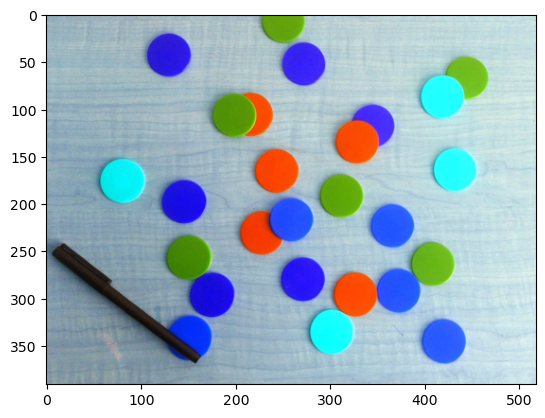

In [5]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

#image_fname = "images/rgb.ppm";
image_fname = "images/coloredChips.png";

rgb = cv.imread( image_fname );
plt.imshow(rgb);

### **Questão 01)** Organização de imagens coloridas

Uma imagem colorida é comummente organizada em 3 matrizes, denominadas canais Red(R), Green(G) e Blue(B), cada uma representando a intensidade luminosa de sua cor correspondente. Assim, um *pixel* colorido é representado por um vetor de intensidades com os canais R, G e B. Na representação RGB, a intensidade de cada *pixel* varia de 0 a 255, sendo 0 a ausência de luminosidade e 255 o brilho máximo do canal. Escreva o código em Python que apresente as componentes R, G, e B da imagem `rgb` de referência. Use a função `subplot` do **Matplotlib** para criar uma linha com 4 imagens, sendo a primeira a imagem de referência e as três últimas os canais R, G e B, respectivamente.

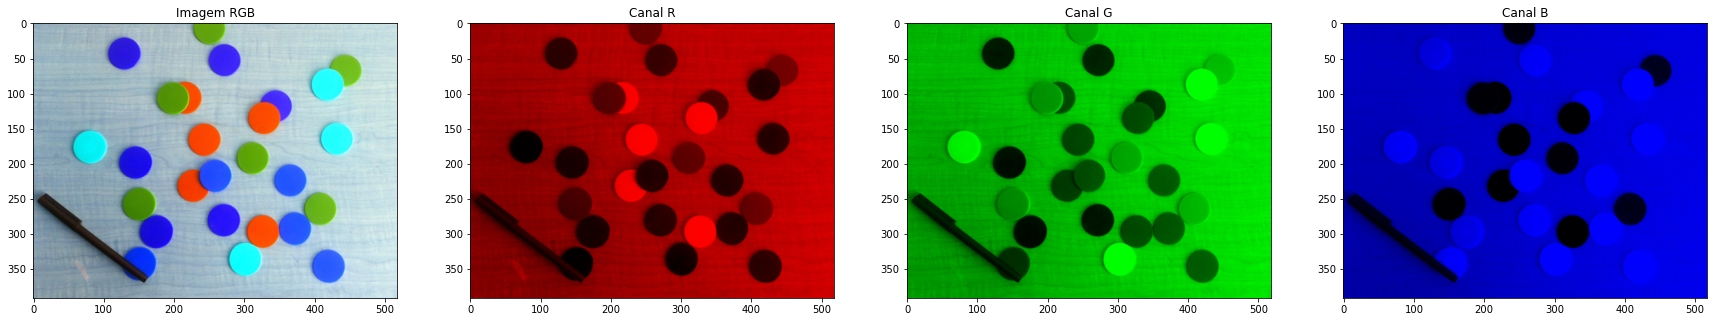

In [100]:
# Atente para a importação do pacote pyplot que já está disponível neste contexto como plt

# Coloque seu código aqui...


### **Questão 02)** Imagem em escala de cinza

Uma imagem em escala de cinza é representada por uma única matriz que contém intensidade de luz do espectro visível para cada *pixel*. Desse modo, em termos mais simples, o valor de cinza de um *pixel* pode ser computado pela média aritmética dos canais R, G e B. Como os cones R, G e B possuem sensibilidades diferentes à luz, o valor de cinza que mais se aproxima da percepção humana é dado pela média ponderada dos canais R, G e B de acordo com a seguinte equação:

$$ gray = 0.2989 \cdot R + 0.5870 \cdot G + 0.1140 \cdot B $$

Para este tópico de estudo, implemente a funcao `rgb2gray` para converter uma imagem RGB e retornar a imagem correspondente em escala de cinza e compare com a função disponibilizada pela **OpenCV**. Ela disponibiliza a função `cv.cvtColor` que permite realizar a conversão em diversos espaços de cores. Crie duas imagens em escala de cinza, `gray` resultante da função `rgb2gray`, esta será a imagem de referência em escala de cinza, e a imagem `gray_cv`, resultante da função `cv.cvtColor`, em seguida, apresente uma linha com 3 figuras usando a biblioteca **Matplotlib**, sendo a primeira a imagem `gray`, a segunda a imagem `gray_cv` e a última uma imagem que contém a diferênça entre as duas imagens geradas.

*Obs.* Na biblioteca **OpenCV**, os *pixels* coloridos podem ser organizados na ordem RGB ou BGR, esse último por questões históricas e também por conveniência de representação numérica de números inteiros em memória. Desse modo, verifique o código de conversão adequado para a sua versão do **OpenCV** e escolha entre `COLOR_RGB2GRAY` e `COLOR_BGR2GRAY` observando a decomposição dos canais RGB na figura anterior.

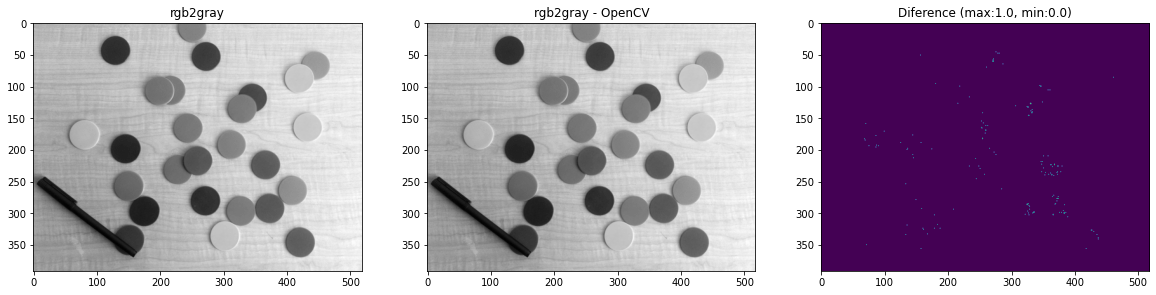

In [101]:
# Complete com seu código

def rgb2gray( rgb ) :
	"""
	rgb - imagem colorida no formato RGB com intensidades variando de 0 -- 255 para cada canal
	return - imagem em escala de cinza com intensidades variando de 0 -- 255
	"""

	
	return gray


gray_cv = cv.cvtColor(rgb, cv.COLOR_RGB2GRAY);
# gray_cv = cv.cvtColor(rgb, cv.COLOR_BGR2GRAY);
gray = rgb2gray(rgb);

# --- Apresentação do resultado --- #
plt.figure(figsize=(20,20));
# ---
plt.subplot(131)
plt.imshow(gray, cmap="gray");
plt.title("rgb2gray");
# ---
plt.subplot(132);
plt.imshow(gray_cv, cmap="gray");
plt.title("rgb2gray - OpenCV");
# ---
plt.subplot(133);
dif = np.abs(gray_cv-gray);
plt.imshow(dif);
tt = "Diference (max:" + str(np.max(dif)) + ", min:" + str(np.min(dif)) + ")";
plt.title(tt);

### **Questão 03)** Espaço de cores HSV

Em Visão Computacional, diferentes espaços de cores podem ser utilizados para representar uma imagem digital. O espaço HSV (Hue, Saturation, Value) é particularmente útil em aplicações nas quais é necessário trabalhar com a informação de cor de forma mais independente da intensidade luminosa.

Considere uma imagem digital representada no espaço de cores RGB, na qual cada pixel é definido pelas componentes (R), (G) e (B), com valores normalizados no intervalo ([0,1]).

Implemente, em Python, uma função que receba uma imagem RGB e produza a sua representação no espaço HSV.

A implementação deve seguir as seguintes restrições:

A função deve receber uma imagem RGB e retornar uma imagem HSV com as mesmas dimensões.
Os valores de (R), (G) e (B) devem ser normalizados para o intervalo ([0,1]), quando necessário.
A conversão deve ser implementada integralmente pelo aluno, utilizando as equações matemáticas de conversão RGB → HSV.
Não é permitido utilizar funções prontas de bibliotecas que realizem diretamente a conversão de RGB para HSV, como cv2.cvtColor(), matplotlib.colors.rgb_to_hsv() ou equivalentes.
A componente H (Hue) deve ser representada em graus, no intervalo ([0,360)).
As componentes S (Saturation) e V (Value) devem estar no intervalo ([0,1]).
A implementação deve tratar corretamente os casos especiais em que:
$(R=G=B);$ onde a saturação é igual a zero;
o valor máximo das componentes RGB é (R), (G) ou (B).
A solução deve utilizar apenas operações matemáticas e estruturas básicas de programação. Bibliotecas como NumPy podem ser utilizadas para manipulação dos arrays, mas não podem ser utilizadas funções que realizem a conversão de espaço de cores.

Equações:

Para cada pixel, inicialmente determine:

$
C_{\max} = \max(R,G,B)
$

$
C_{\min} = \min(R,G,B)
$

$
\Delta = C_{\max}-C_{\min}
$

A componente V é dada por:

$
V=C_{\max}
$

A componente S é:

$
S =
\begin{cases}
0, & C_{\max}=0\
\frac{\Delta}{C_{\max}}, & C_{\max}\neq0
\end{cases}
$

A componente H é determinada por:

$
H =
\begin{cases}
0, & \Delta=0\
60\left(\frac{G-B}{\Delta}\right)\mod 360, & C_{\max}=R\
60\left(\frac{B-R}{\Delta}+2\right), & C_{\max}=G\
60\left(\frac{R-G}{\Delta}+4\right), & C_{\max}=B
\end{cases}
$

In [ ]:
import numpy as np


def rgb_to_hsv(image_rgb):
    """
    Converte uma imagem RGB para HSV sem utilizar funções
    prontas de conversão de espaço de cores.

    Entrada:
        image_rgb:
            Array NumPy com dimensão (altura, largura, 3).
            Os valores RGB podem estar em [0, 255] ou [0, 1].

    Saída:
        image_hsv:
            Array NumPy com dimensão (altura, largura, 3).

            H: [0, 360)
            S: [0, 1]
            V: [0, 1]
    """

	# Coloque seu código aqui...

    return image_hsv


#### **Apresentação do resultado**

Após implementar a função, teste-a convertendo uma imagem e apresentando os canais HSV separadamente, como níveis de cinza.

Apresente:

os testes realizados;
os resultados obtidos;
uma breve explicação de como o algoritmo determina cada componente HSV.

In [ ]:
### Coloque seu código aqui ...

#### Alguns pixels para teste

Para os principais pixels utilizados no teste:

| RGB             |    H |  S |      V |
| --------------- | ---: | -: | -----: |
| (255, 0, 0)     |   0° |  1 |      1 |
| (0, 255, 0)     | 120° |  1 |      1 |
| (0, 0, 255)     | 240° |  1 |      1 |
| (255, 255, 255) |   0° |  0 |      1 |
| (0, 0, 0)       |   0° |  0 |      0 |
| (255, 255, 0)   |  60° |  1 |      1 |
| (255, 0, 255)   | 300° |  1 |      1 |
| (128, 128, 128) |   0° |  0 | ≈0,502 |

O ponto mais importante da implementação é que **nenhuma função de conversão de espaço de cores é utilizada**. O algoritmo calcula diretamente (C_{\max}), (C_{\min}), (\Delta), (H), (S) e (V) para cada pixel. **Não se preocupe com a eficiência do algoritmo!**.


### **Questão 04)**  Conversão de RGB para CIELAB (Opcional - somente para os mais hardcore)

_**Um pouco mais desafiadora**_

O espaço de cores CIELAB (CIE L*a*b*) foi desenvolvido para representar as cores de maneira mais próxima da percepção visual humana. Diferentemente do RGB, suas componentes possuem interpretações relacionadas à luminosidade e às características cromáticas da cor.

Considere uma imagem digital representada no espaço de cores RGB, com valores das componentes (R), (G) e (B) no intervalo ([0,255]).

Implemente, em Python, uma função que receba uma imagem RGB e produza sua representação no espaço de cores CIELAB.

A implementação deve seguir as seguintes restrições:

- A função deve receber uma imagem RGB e retornar uma imagem CIELAB com as mesmas dimensões.
- A conversão deve ser implementada pelo aluno, seguindo as etapas matemáticas de conversão RGB → CIELAB.
- Não é permitido utilizar funções prontas de bibliotecas para conversão de espaços de cores, como cv2.cvtColor(), skimage.color.rgb2lab() ou equivalentes.
- Bibliotecas como NumPy podem ser utilizadas para operações matriciais e manipulação dos arrays.

A implementação real dessa função realiza as seguintes etapas (em sequência):
- normalização dos valores RGB;
- conversão de RGB para XYZ;
- normalização em relação ao ponto branco de referência;
- aplicação da função não linear utilizada na conversão XYZ → CIELAB;
- cálculo das componentes (L^), (a^) e (b^*).


Considere o ponto branco D65, utilizando:

$
X_n = 0.95047,\qquad
Y_n = 1.00000,\qquad
Z_n = 1.08883
$

Para a conversão de RGB para XYZ, utilize:

$
\begin{bmatrix}
0.4124564 & 0.3575761 & 0.1804375\
0.2126729 & 0.7151522 & 0.0721750\
0.0193339 & 0.1191920 & 0.9503041
\end{bmatrix}
\begin{bmatrix}
R\
G\
B
\end{bmatrix}
$

Antes dessa transformação, considere que os valores RGB devem ser convertidos de sRGB para RGB linearizado.

Utilize:

$
C_{lin} =
\begin{cases}
\frac{C}{12.92}, & C \leq 0.04045\
\left(\frac{C+0.055}{1.055}\right)^{2.4}, & C>0.04045
\end{cases}
$
para cada componente (R), (G) e (B).


Após obter (X), (Y) e (Z), calcule:
$
f(t)=
\begin{cases}
t^{1/3}, & t>\delta^3\
\frac{t}{3\delta^2}+\frac{4}{29}, & t\leq\delta^3
\end{cases}
$

onde:

$
\delta=\frac{6}{29}
$

Então, determine:

$
L^* = 116f\left(\frac{Y}{Y_n}\right)-16
$

$
a^* = 500
\left[
f\left(\frac{X}{X_n}\right)-
f\left(\frac{Y}{Y_n}\right)
\right]
$

$
b^* = 200
\left[
f\left(\frac{Y}{Y_n}\right)-
f\left(\frac{Z}{Z_n}\right)
\right]
$

Questões complementares

a) Explique o significado das três componentes (L^), (a^) e (b^*).

b) Explique por que o CIELAB é considerado um espaço de cores aproximadamente perceptualmente uniforme.

c) Explique por que a etapa de linearização do sRGB é necessária antes da transformação para XYZ.

d) Implemente a função rgb_to_lab(image_rgb) sem utilizar funções prontas de conversão de espaço de cores.

e) Teste sua implementação utilizando, no mínimo, os pixels RGB correspondentes a preto, branco, vermelho, verde, azul e cinza. Apresente os valores (L^), (a^) e (b^*) obtidos.

f) Explique como a distância euclidiana entre dois pontos no espaço CIELAB pode ser utilizada para estimar a diferença perceptual entre duas cores.



**Apresentação do resultado**

Crie um código que apresenta os canalis Lab como canais independentes em escala de cinza.

In [ ]:
### Coloque seu código aqui ...

# Considere o seguinte código

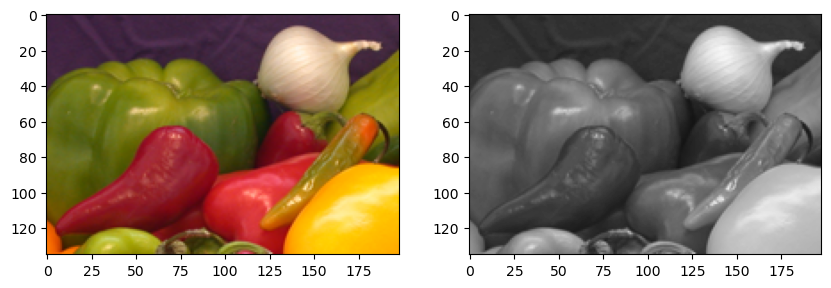

In [ ]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import NoNorm
from matplotlib.widgets import RangeSlider

# fname = "images/lena.ppm"
# fname = "images/coloredChips.png"
fname = "images/onion.png"

rgb = cv.cvtColor(cv.imread( fname ), cv.COLOR_BGR2RGB);
gray = cv.cvtColor(rgb, cv.COLOR_RGB2GRAY);

fig_imref = plt.figure( figsize=(10,10) )
plt.subplot(121);
plt.imshow(rgb);
plt.subplot(122);
plt.imshow(gray, cmap="gray", norm=NoNorm() );


### **Questão 05)** Operações Pontuais
Implemente uma função realize a correção Gamma de uma imagem em escala de cinza. Para isso, a função deve receber uma imagem em escala de cinza e o parâmetro $\gamma$, indicando o fator de correção de acordo com a seguinte equação abaixo. Considere $r$ o *pixel* de entrada e $s$ o *pixel* de saída. Apresente resultados para a imagem de exemplo deste *notebook* para os valores de $\gamma=3$ e $\gamma=1/3$. A função `imshow` normaliza a apresentação de imagem em escala de cinza por padrão. Para remover esse comportamento, desabilite a normalização passando o seguinte argumento `norm=NoNorm()` para a função `imshow`.

$$
s=255\times\left(\frac{r}{255}\right)^\gamma
$$

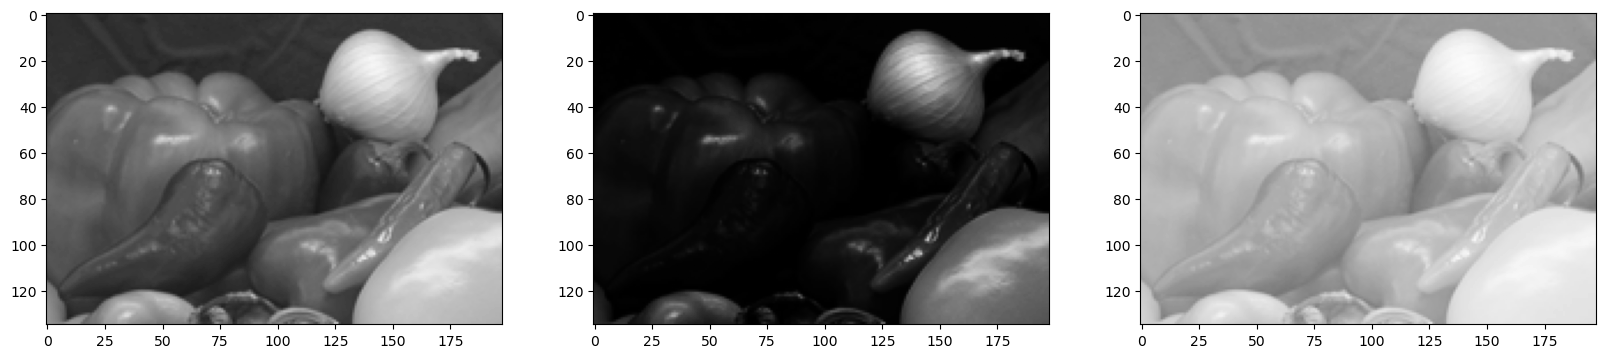

In [ ]:
def gamma_correction( gray, gamma ) :
	"""
	gray - imagem em escala de cinza
	gamma - fator de correção gamma
    """
	# Put your code here!
 
	return img


# --- Apresentação do resultado --- #
plt.figure(figsize=(20,20));

gamma = 3;
plt.subplot(131);
plt.imshow(gray, cmap="gray", norm=NoNorm())
plt.subplot(132);
plt.imshow(gamma_correction(gray,gamma), cmap="gray", norm=NoNorm())
plt.subplot(133);
plt.imshow(gamma_correction(gray,1/gamma), cmap="gray", norm=NoNorm())
    

### **Questão 02)** Conversão de cores e binarização

Os espaços `HSV` e `CIEL*a*b*` são modelos de cor definidos por três componentes. Enquanto o modelo `HSV` constitui uma forma mais intuitiva de entender as componentes de uma cor, o modelo `CIEL*a*b*` se aproxima da percepção humana ao estímulo da cor. Ambos modelos apresentam vantagens em tarefas de segmentação quando comparadas ao modelo `RGB` tradicional. Apresente um grid de avaliação do processo de segmentação/binarização de cada canal de ambos os espaços de cores. Crie uma matriz $3\times 3$, sendo a primeira linha formada pela imagem `RGB`, `HSV` e `CIEL*a*b*`. A segunda linha o resultado da binarização de cada canal `HSV` e a terceira linha o resultado da binarização de cada canal `CIEL*a*b*`. Para converter a imagem entre os espaços de cores, use a biblioteca OpenCV. A binarização deve ser feita buscando o valor ótimo dado pelo método de Otsu. Para isso, use o seguinte código:

<code> _, th = cv.threshold(img_hsv[:,:,channel],0,255,cv.THRESH_BINARY+cv.THRESH_OTSU) </code>

Discuta os resultados para a máscara binária gerada em cada canal avaliado.

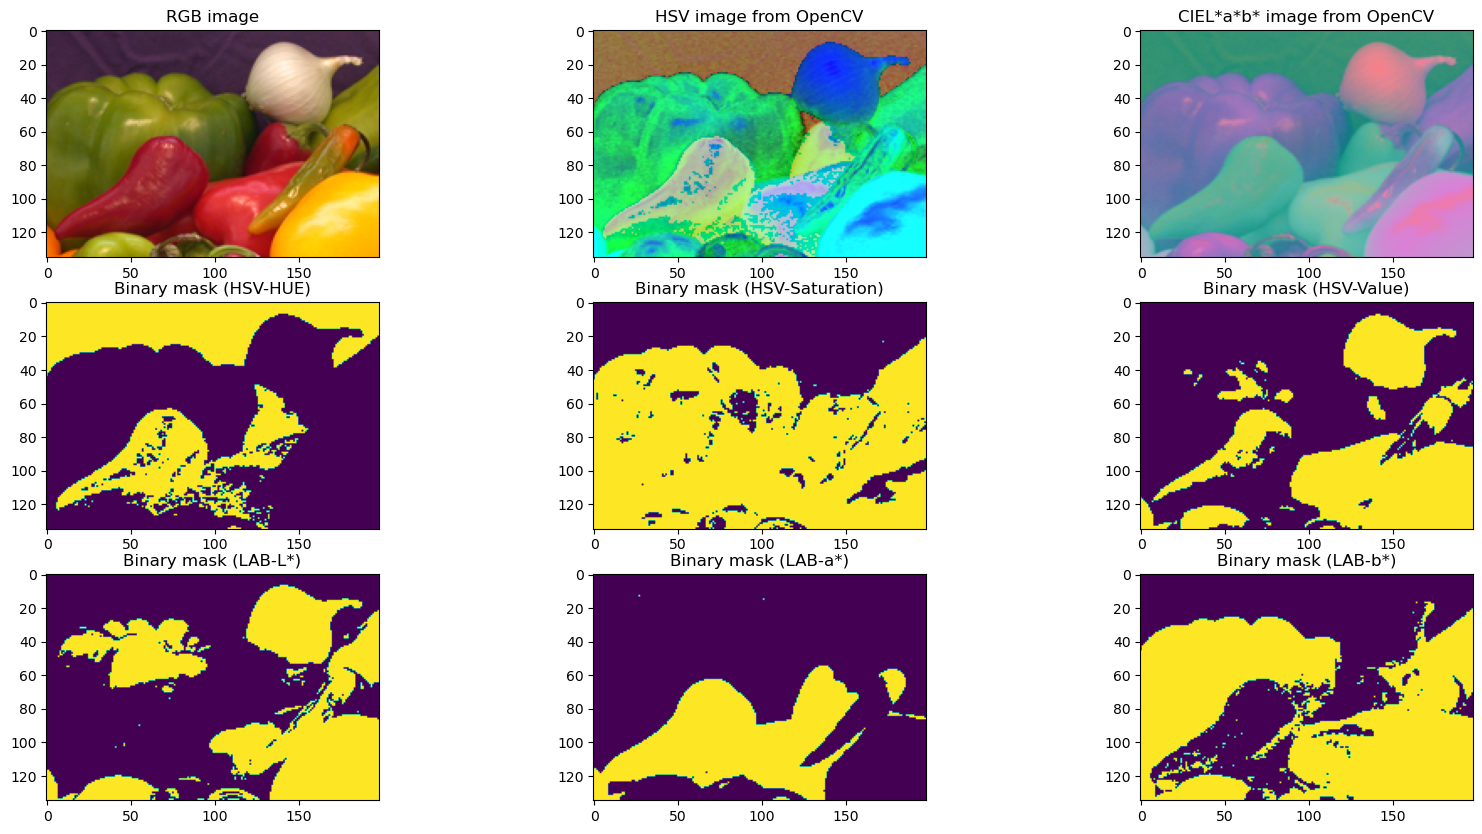

In [ ]:

#_, th = cv.threshold(img[:,:,channel],0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)

# Put your code here!
